# 03 — LangGraph RAG Pipeline: Visualization & E2E Test

Compile the agentic RAG graph, render the architecture diagram,
and run 5 queries end-to-end while printing state at each node.

In [1]:
import sys
from pathlib import Path

CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("/teamspace/studios/this_studio"),
]
ROOT = None
for candidate in CANDIDATES:
    if (candidate / "src").exists() and (candidate / "data").exists():
        ROOT = candidate.resolve()
        break

if ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing both src/ and data/.")

for p in [ROOT, ROOT / 'src']:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

print('Root:', ROOT)

Root: /teamspace/studios/this_studio


In [2]:
from config.config import SEED
from src.utils.seed import set_seed

set_seed(SEED)
print(f'Seed set to {SEED}')

Seed set to 42


In [3]:
from src.model.loader import load_model_and_tokenizer
from src.model.llm_wrapper import QuantizedHFLLM, register_llm

loaded = load_model_and_tokenizer()
llm = QuantizedHFLLM(
    model=loaded.model,
    tokenizer=loaded.tokenizer,
    max_new_tokens=220,
    min_new_tokens=64,
    temperature=0.0,
)
register_llm(llm)
print('LLM registered:', type(llm).__name__)

/teamspace/studios/this_studio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM registered: QuantizedHFLLM


## Compile & Visualize the Graph

In [4]:
from src.graph.graph import build_graph, compile_graph

app = compile_graph()
print('Graph compiled successfully.')
print('Nodes:', list(build_graph().nodes.keys()))

Graph compiled successfully.
Nodes: ['planner', 'retriever', 'generator', 'critic', 'retry_counter', 'synthesizer']


Saved architecture diagram to /teamspace/studios/this_studio/docs/architecture.png


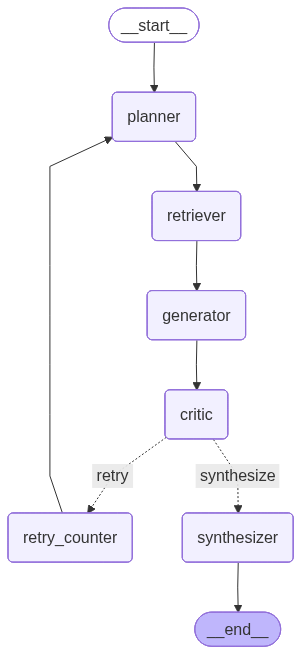

In [5]:
from pathlib import Path
from IPython.display import Image, display

docs_dir = ROOT / 'docs'
docs_dir.mkdir(exist_ok=True)

png_bytes = app.get_graph().draw_mermaid_png()
out_path = docs_dir / 'architecture.png'
out_path.write_bytes(png_bytes)
print(f'Saved architecture diagram to {out_path}')
display(Image(png_bytes))

## End-to-End Runs (5 queries)

Run 5 representative queries through the full graph and inspect the state
at each node to verify correct loop triggering and exit behavior.

In [6]:
TEST_QUERIES = [
    'Does metformin reduce cardiovascular mortality in type 2 diabetes?',
    'Is cognitive behavioural therapy effective for treatment-resistant depression?',
    'What is the role of BRCA1 mutation in breast cancer risk?',
    'Can aspirin prevent colorectal cancer in high-risk patients?',
    'Does sleep deprivation impair immune function?',
]

print(f'{len(TEST_QUERIES)} queries loaded')

5 queries loaded


In [7]:
import textwrap

all_results = []

for idx, query in enumerate(TEST_QUERIES, start=1):
    print('=' * 100)
    print(f'[{idx}] QUERY: {query}')
    print('=' * 100)

    # Stream node-by-node to inspect intermediate state
    final_state = None
    for step in app.stream({'query': query, 'retry_count': 0}, stream_mode='updates'):
        for node_name, node_output in step.items():
            print(f'  >> NODE: {node_name}')
            # Print a summary of what this node produced
            for key, val in node_output.items():
                if key == 'retrieved_docs':
                    print(f'     {key}: {len(val)} chunks')
                elif key == 'sub_queries':
                    for i, sq in enumerate(val, 1):
                        print(f'     sub_query {i}: {sq}')
                elif key in ('draft_answer', 'final_answer'):
                    preview = str(val)[:200].replace('\n', ' ')
                    print(f'     {key}: {preview}...')
                else:
                    print(f'     {key}: {val}')
            final_state = node_output

    # Collect result from the last invoke for summary table
    result = app.invoke({'query': query, 'retry_count': 0})
    all_results.append(result)

    print(f'\n  FAITHFULNESS SCORE : {result.get("faithfulness_score", "n/a")}')
    print(f'  RETRY COUNT       : {result.get("retry_count", 0)}')
    print(f'  CITATIONS         : {result.get("citations", [])}')
    print(f'  FINAL ANSWER:')
    print(textwrap.fill(result.get('final_answer', '(none)')[:400], width=100))
    print()

print('All 5 queries processed.')

[1] QUERY: Does metformin reduce cardiovascular mortality in type 2 diabetes?
  >> NODE: planner
     query: Does metformin reduce cardiovascular mortality in type 2 diabetes?
     retry_count: 0
     sub_query 1: Does metformin reduce cardiovascular mortality in type 2 diabetes


  >> NODE: retriever
     query: Does metformin reduce cardiovascular mortality in type 2 diabetes?
     sub_query 1: Does metformin reduce cardiovascular mortality in type 2 diabetes
     retry_count: 0
     retrieved_docs: 2 chunks
  >> NODE: generator
     query: Does metformin reduce cardiovascular mortality in type 2 diabetes?
     sub_query 1: Does metformin reduce cardiovascular mortality in type 2 diabetes
     retrieved_docs: 2 chunks
     retry_count: 0
     draft_answer: , hypoglycemia, and adverse events.'], 'labels': ['OBJECTIVE', 'STUDY DESIGN', 'POPULATION', 'INTERVENTIONS', 'OUTCOMES MEASURED', 'RESULTS'], 'meshes': ['Analysis of Variance', 'Diabetes Mellitus, Ty...
  >> NODE: critic
     query: Does metformin reduce cardiovascular mortality in type 2 diabetes?
     sub_query 1: Does metformin reduce cardiovascular mortality in type 2 diabetes
     retrieved_docs: 2 chunks
     draft_answer: , hypoglycemia, and adverse events.'], 'labels': ['OBJECTIVE', 'STUDY DESIGN', 

In [ ]:
import pandas as pd

rows = []
for r in all_results:
    rows.append({
        'query': r.get('query', '')[:80],
        'sub_queries': len(r.get('sub_queries', [])),
        'chunks': len(r.get('retrieved_docs', [])),
        'faithfulness': round(r.get('faithfulness_score', 0.0), 3),
        'retries': r.get('retry_count', 0),
        'citations': len(r.get('citations', [])),
        'answer_preview': r.get('final_answer', '')[:150].replace('\n', ' '),
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 140)
df

,query,sub_queries,chunks,faithfulness,retries,citations,answer_preview
0,Does metformin reduce cardiovascular mortality in type 2 diabetes?,1,2,0.274,2,2,", hypoglycemia, and adverse events.'], 'labels': ['OBJECTIVE', 'STUDY DESIGN', 'POPULATION', 'INTERVENTIONS', 'OUTCOMES MEASURED', 'RESU..."
1,Is cognitive behavioural therapy effective for treatment-resistant depression?,1,2,0.997,0,2,Medical disclaimer: This output is informational only and must not be used as a substitute for licensed clinical judgment. The duration...
2,What is the role of BRCA1 mutation in breast cancer risk?,1,2,0.513,2,2,"9) for BRCA2 carriers. The best model for BRCA1 carriers included age, age at menarche, age at menopause, and a SNP score. For BRCA2 car..."
3,Can aspirin prevent colorectal cancer in high-risk patients?,1,2,0.908,0,2,"Up Studies', 'Humans', 'Male', 'Prospective Studies', 'Retrospective Studies', 'Time Factors', 'Ulcerative Colitis', 'Young Adult'], 're..."
4,Does sleep deprivation impair immune function?,1,2,0.859,0,2,"'Female', 'Humans', 'Male', 'Middle Aged', 'Mortality', 'Mortality and Survival', 'Near-Infrared Spectroscopy', 'Pain', 'Pain Measuremen..."


: 

## Verification Checklist

- [ ] Graph compiles without error and diagram renders.
- [ ] Planner decomposes each query into 2–3 sub-questions.
- [ ] Retriever returns deduplicated chunks across sub-queries.
- [ ] Generator produces grounded answers with `[chunk_id]` citations.
- [ ] Critic scores faithfulness; low scores trigger retry loop.
- [ ] Retry loop exits correctly after `MAX_RETRIES` or passing threshold.
- [ ] Synthesizer appends references and safety disclaimer where needed.
- [ ] Architecture diagram saved to `docs/architecture.png`.